In [1]:
import model as m
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
import numpy as np

### Parameter Values

Controllable Parameters

name | units | description
--- | --- | --- 
$K$ | `f` | carrying capacity of frog saunas, a function of $u_1$
$\xi$ | `1 / t` | rate of transfer into antifungal treatment, a function of $u_2$

Constant Parameters

name | units | description
--- | --- | --- 
$\alpha$ | `1 / f / t` | infection rate from living hosts
$\beta$ | `1 / t` | death rate from disease
$\gamma$ | `1 / f / t` | rate that frogs leave sauna
$\zeta$ | `1 / t` | rate of transfer to heat treatment
$\eta$ | `1` (unitless) | success rate of antifungal bath treatment

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 7.000e+03  6.994e+03 ...  4.427e+01  4.427e+01]
            [ 1.000e+03  1.005e+03 ...  3.845e+01  3.841e+01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  1.003e+00 ...  7.917e+03  7.917e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 104
     njev: 0
      nlu: 0

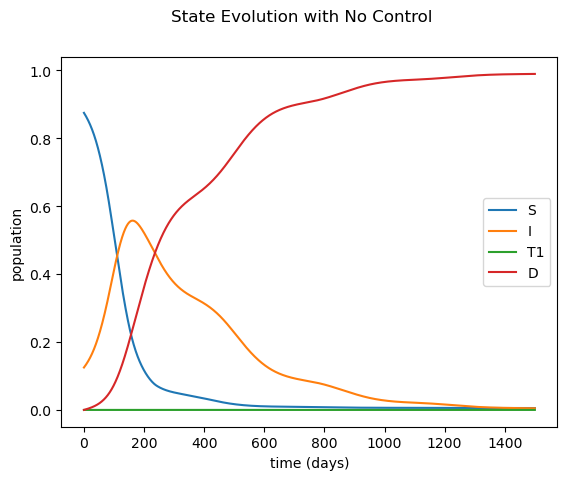

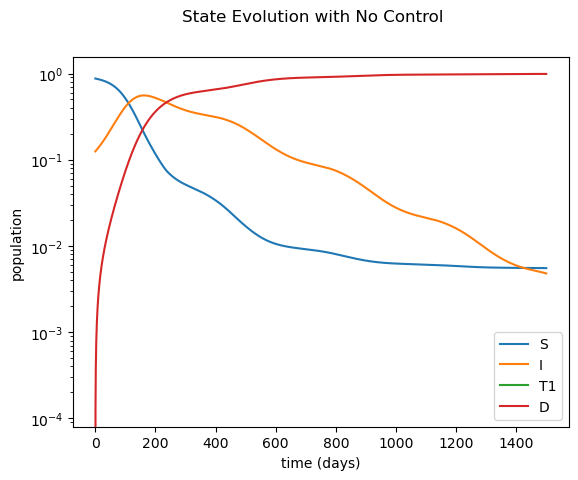

In [2]:
# No Controls, autonomous evolution, seasonal

tsteps = 3000

# params
y_init = np.array([7000, 1000, 0, 0]) # 4k for y_init susceptible and infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 0, 0 # we have no frog hotels
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.0000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.006) + (0.006 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with No Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.002e-01 ...  1.499e+03  1.500e+03]
        y: [[ 4.000e+03  3.904e+03 ...  2.163e+03  2.162e+03]
            [ 4.000e+03  3.919e+03 ...  8.584e-01  8.561e-01]
            [ 0.000e+00  1.730e+02 ...  1.726e+02  1.727e+02]
            [ 0.000e+00  3.941e+00 ...  5.664e+03  5.664e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 7784
     njev: 0
      nlu: 0

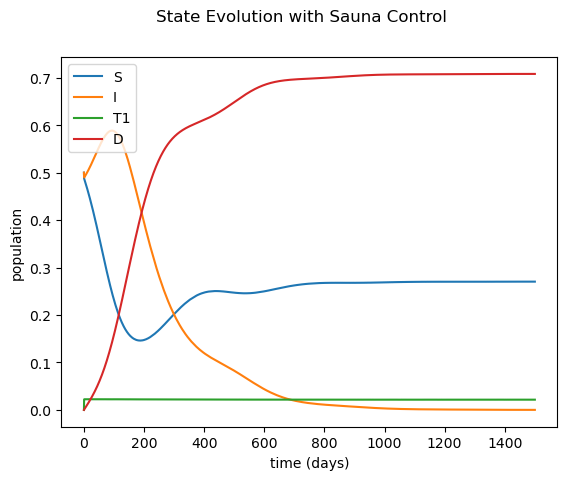

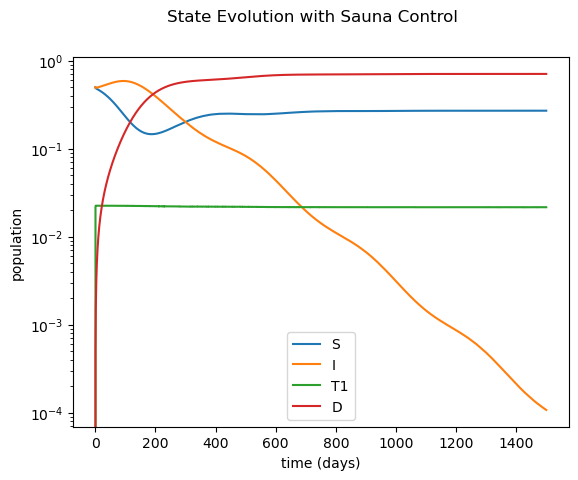

In [3]:
# $1 / day in Frog Sauna, autonomous evolution

tsteps = 3000

# params
y_init = np.array([4000, 4000, 0, 0]) # 4k for y_init susceptible and infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 1, 0 # we have some frog hotels
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.0000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.006) + (0.006 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1500
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.003e-01 ...  9.995e+02  1.000e+03]
        y: [[ 4.000e+03  3.988e+03 ...  4.763e+02  4.765e+02]
            [ 4.000e+03  4.008e+03 ...  4.039e+01  4.010e+01]
            [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
            [ 0.000e+00  4.006e+00 ...  7.483e+03  7.483e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 110
     njev: 0
      nlu: 0

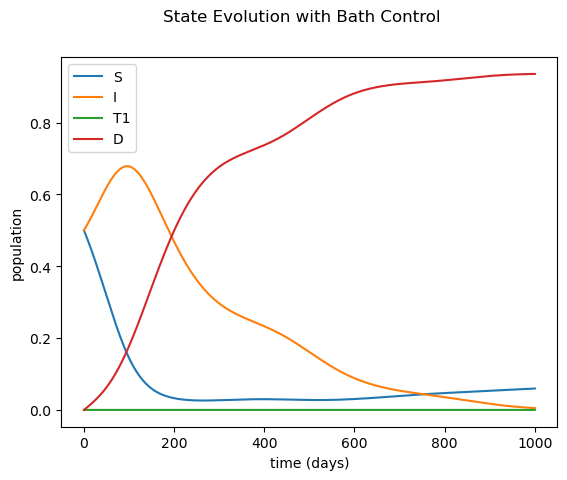

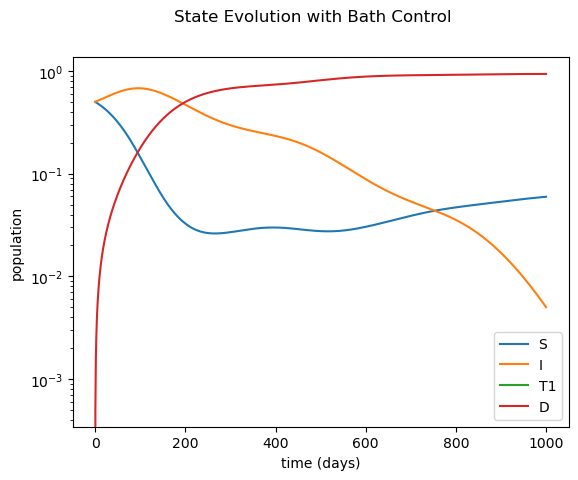

In [4]:
# $1000 / day in Frog treatment, autonomous evolution

tsteps = 2000

# params
y_init = np.array([4000, 4000, 0, 0]) # 4k for y_init susceptible and infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 0, 100 # we have some frog bathers
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.0000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.006) + (0.006 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1000
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  5.003e-01 ...  9.995e+02  1.000e+03]
        y: [[ 4.000e+03  3.905e+03 ...  2.424e+03  2.424e+03]
            [ 4.000e+03  3.918e+03 ...  1.452e-01  1.433e-01]
            [ 0.000e+00  1.730e+02 ...  1.738e+02  1.736e+02]
            [ 0.000e+00  3.941e+00 ...  5.402e+03  5.402e+03]]
      sol: None
 t_events: None
 y_events: None
     nfev: 6056
     njev: 0
      nlu: 0

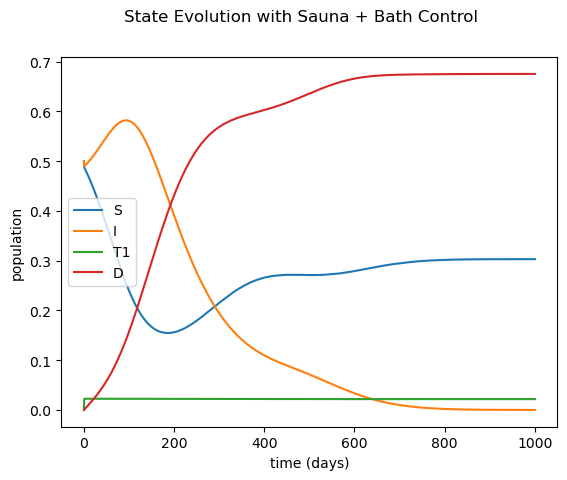

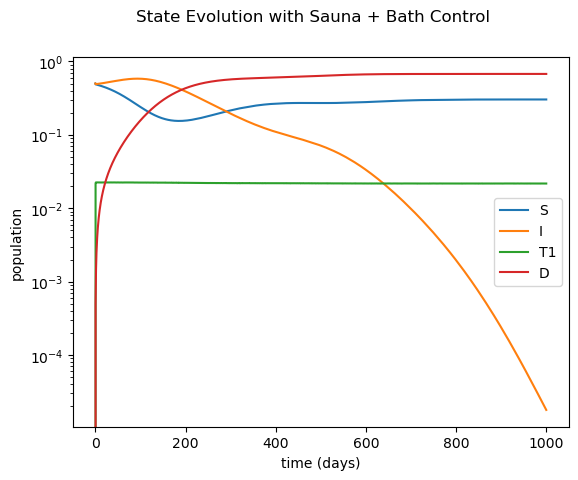

In [5]:
# $1000 / day in Frog treatment, $10 in sauna, autonomous evolution

tsteps = 2000

# params
y_init = np.array([4000, 4000, 0, 0]) # 4k for y_init susceptible and infected
gamma, zeta = 0.1, 0.15 # central time average parameter estimates
K, eta, xi = lambda u1: 365 * u1 / 2, lambda u2: 1, lambda u2, I: u2 / (I + 50) / 100 # control functions
control1 = 1, 100 # we have some frog bathers
control2 = K, eta, xi # other parameters

# season starts in summer
theta = lambda t: 2 * np.pi * t / 365
alpha = lambda theta: 0.0000025 * (1 + 0.5 * np.cos(theta + 1.25 * np.pi)) # seasonal alpha
beta = lambda theta: ((0.002 + 0.006) + (0.006 - 0.002) * np.cos(theta + np.pi))/2 # seasonal beta

# solve for tf days
t0, tf = 0, 1000
sol = solve_ivp(
    m.model_equation,
    t_span=[t0, tf],
    y0=y_init,
    t_eval=np.linspace(t0, tf, tsteps),
    args=[theta, control1, control2, alpha, gamma, zeta, beta]
    )

display(sol)

# graph each compartment
plt.plot(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.plot(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.plot(sol.t, sol.y[2] / np.sum(y_init), label="T1")
plt.plot(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna + Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()

plt.show()

# log log

plt.semilogy(sol.t, sol.y[0] / np.sum(y_init), label='S')
plt.semilogy(sol.t, sol.y[1] / np.sum(y_init), label="I")
plt.semilogy(sol.t, sol.y[2] / np.sum(y_init), label="T1")
# plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="T2")
plt.semilogy(sol.t, sol.y[3] / np.sum(y_init), label="D")

# label the graph
plt.suptitle(fr"State Evolution with Sauna + Bath Control")
plt.xlabel("time (days)")
plt.ylabel("population")
plt.legend()